# 1. Importing modules

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


In [2]:
file = "C:/Users/USER-PC/QSAR_Code/Oral toxicity/dataset/Acute_Oral.sdf"

sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

[16:47:08] Can't kekulize mol.  Unkekulized atoms: 63 64 65 66 67
[16:47:08] ERROR: Could not sanitize molecule ending on line 5243
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized atoms: 63 64 65 66 67
[16:47:08] Can't kekulize mol.  Unkekulized atoms: 0 46 47 48 49 50 51 52 53
[16:47:08] ERROR: Could not sanitize molecule ending on line 11412
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized atoms: 0 46 47 48 49 50 51 52 53
[16:47:08] Can't kekulize mol.  Unkekulized atoms: 10 11 12 14 15 16 17 18 19
[16:47:08] ERROR: Could not sanitize molecule ending on line 13872
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized atoms: 10 11 12 14 15 16 17 18 19
[16:47:08] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 12
[16:47:08] ERROR: Could not sanitize molecule ending on line 14010
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 12
[16:47:08] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 12
[16:47:08] ERROR: Could not sanitize molecule e

[16:47:08] Can't kekulize mol.  Unkekulized atoms: 2 3 4 6 7
[16:47:08] ERROR: Could not sanitize molecule ending on line 65522
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized atoms: 2 3 4 6 7
[16:47:08] Can't kekulize mol.  Unkekulized atoms: 9 10 12 13 14
[16:47:08] ERROR: Could not sanitize molecule ending on line 65622
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized atoms: 9 10 12 13 14
[16:47:08] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 12
[16:47:08] ERROR: Could not sanitize molecule ending on line 66948
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 12
[16:47:08] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 21
[16:47:08] ERROR: Could not sanitize molecule ending on line 78254
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 21
[16:47:08] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20
[16:47:08] ERROR: Could not sanitize molecule ending on line 80629
[16:47:08] ERROR: Can't kekulize mol.  Unkekulized 

[16:47:09] ERROR: Could not sanitize molecule ending on line 306460
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8 9 10 11 16
[16:47:09] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 10 11 12
[16:47:09] ERROR: Could not sanitize molecule ending on line 306869
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 10 11 12
[16:47:09] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 7 8 9 14 15
[16:47:09] ERROR: Could not sanitize molecule ending on line 307722
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 7 8 9 14 15
[16:47:09] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8 9 10 11 16
[16:47:09] ERROR: Could not sanitize molecule ending on line 310201
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8 9 10 11 16
[16:47:09] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 9 11
[16:47:09] ERROR: Could not sanitize molecule ending on line 310510
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 

[16:47:09] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 11 12 13
[16:47:09] ERROR: Could not sanitize molecule ending on line 366925
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 11 12 13
[16:47:09] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 12
[16:47:09] ERROR: Could not sanitize molecule ending on line 367401
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 12
[16:47:09] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 7 8 9 10 15
[16:47:09] ERROR: Could not sanitize molecule ending on line 369220
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 7 8 9 10 15
[16:47:09] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 16
[16:47:09] ERROR: Could not sanitize molecule ending on line 369674
[16:47:09] ERROR: Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 16
[16:47:09] Can't kekulize mol.  Unkekulized atoms: 0 1 3 4 5
[16:47:09] ERROR: Could not sanitize molecule ending on line 370176
[

[16:47:10] Explicit valence for atom # 22 O, 3, is greater than permitted
[16:47:10] ERROR: Could not sanitize molecule ending on line 494681
[16:47:10] ERROR: Explicit valence for atom # 22 O, 3, is greater than permitted
[16:47:10] Can't kekulize mol.  Unkekulized atoms: 0 1 3 4 5
[16:47:10] ERROR: Could not sanitize molecule ending on line 497655
[16:47:10] ERROR: Can't kekulize mol.  Unkekulized atoms: 0 1 3 4 5
[16:47:10] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 11 12 13
[16:47:10] ERROR: Could not sanitize molecule ending on line 503193
[16:47:10] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 11 12 13
[16:47:10] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[16:47:10] ERROR: Could not sanitize molecule ending on line 503566
[16:47:10] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[16:47:10] Can't kekulize mol.  Unkekulized atoms: 0 9 10 11 12 13 16 17 18
[16:47:10] ERROR: Could not sanitize molecule ending on line 516857
[16:47:10] ERROR: Ca

[16:47:10] Explicit valence for atom # 5 O, 3, is greater than permitted
[16:47:10] ERROR: Could not sanitize molecule ending on line 699097
[16:47:10] ERROR: Explicit valence for atom # 5 O, 3, is greater than permitted
[16:47:10] Can't kekulize mol.  Unkekulized atoms: 9 10 12 13 14
[16:47:10] ERROR: Could not sanitize molecule ending on line 704531
[16:47:10] ERROR: Can't kekulize mol.  Unkekulized atoms: 9 10 12 13 14
[16:47:10] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9 10 11 12 13
[16:47:10] ERROR: Could not sanitize molecule ending on line 712478
[16:47:10] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9 10 11 12 13
[16:47:10] Explicit valence for atom # 1 O, 3, is greater than permitted
[16:47:10] ERROR: Could not sanitize molecule ending on line 726182
[16:47:10] ERROR: Explicit valence for atom # 1 O, 3, is greater than permitted
[16:47:10] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:47:10] ERROR: Could not sanitize molecule e

(8212, 18)
(8212, 18)


Index(['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'SMILES', 'Mol',
       'GHS_category', 'EPA_category', 'LD50_mgkg'],
      dtype='object')

In [3]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

In [4]:
moldf.head(1)

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,StandardizerResult,Outcome,ID,SMILES,Mol,GHS_category,EPA_category,LD50_mgkg
0,5894-60-0,DTXSID10884196,"Silane, trichlorohexadecyl-",EPA_DSSTox,CCCCCCCCCCCCCCCC[Si](Cl)(Cl)Cl,?,InChI=1S/C16H33Cl3Si/c1-2-3-4-5-6-7-8-9-10-11-...,RYPYGDUZKOPBEL-UHFFFAOYSA-N,FALSE,FALSE,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,1,5894-60-0,CCCCCCCCCCCCCCCC[Si](Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000002264D5...,NaN,NaN,NaN


In [5]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf['RowID'] = moldf.index
moldf.head(100)

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,StandardizerResult,Outcome,ID,SMILES,Mol,GHS_category,EPA_category,LD50_mgkg,RowID
8064,20769-85-1,DTXSID7045077,2-Bromo-2-methylpropionyl bromide,EPA_DSSTox,CC(C)(Br)C(=O)Br,?,"InChI=1S/C4H6Br2O/c1-4(2,6)3(5)7/h1-2H3",YOCIJWAHRAJQFT-UHFFFAOYSA-N,FALSE,NA,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,,20769-85-1,CC(C)(Br)C(=O)Br,<rdkit.Chem.rdchem.Mol object at 0x00000226575...,NaN,NaN,NaN,8064
7612,25321-41-9,DTXSID4027860,Xylenesulfonic acid,EPA_DSSTox,CC1C(=CC=CC=1C)S(O)(=O)=O,?,"InChI=1S/C8H10O3S/c1-6-4-3-5-8(7(6)2)12(9,10)1...",ZZXDRXVIRVJQBT-UHFFFAOYSA-N,FALSE,NA,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,,25321-41-9,Cc1cccc(S(=O)(=O)O)c1C,<rdkit.Chem.rdchem.Mol object at 0x00000226574...,NaN,3,NaN,7612
8339,30989-05-0,DTXSID40184974,Tris(2-(2-(2-methoxyethoxy)ethoxy)ethyl) ortho...,EPA_DSSTox,COCCOCCOCCOB(OCCOCCOCCOC)OCCOCCOCCOC,?,InChI=1S/C21H45BO12/c1-23-4-7-26-10-13-29-16-1...,BYRJZJXBVKUYFH-UHFFFAOYSA-N,FALSE,NA,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,,30989-05-0,COCCOCCOCCOB(OCCOCCOCCOC)OCCOCCOCCOC,<rdkit.Chem.rdchem.Mol object at 0x00000226585...,NaN,NaN,NaN,8339
8340,3332-27-2,DTXSID2029660,"1-Tetradecanamine, N,N-dimethyl-, N-oxide",EPA_DSSTox,CCCCCCCCCCCCCC[N+](C)(C)[O-],?,InChI=1S/C16H35NO/c1-4-5-6-7-8-9-10-11-12-13-1...,ONHFWHCMZAJCFB-UHFFFAOYSA-N,FALSE,NA,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,,3332-27-2,CCCCCCCCCCCCCC[N+](C)(C)[O-],<rdkit.Chem.rdchem.Mol object at 0x00000226585...,NaN,NaN,NaN,8340
7611,6685-76-3,DTXSID70216974,"Carbonic acid, compound with phenylguanidine (...",EPA_DSSTox,NC(N)=NC1C=CC=CC=1,OC(O)=O,"InChI=1S/C7H9N3/c8-7(9)10-6-4-2-1-3-5-6/h1-5H,...",QRJZGVVKGFIGLI-UHFFFAOYSA-N,FALSE,NA,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,,6685-76-3,NC(N)=Nc1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x00000226574...,NaN,3,NaN,7611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7070,4056-77-3,NaN,,Public_CrossChecked,CCCCOC(=O)C1CC(CC1)C(=O)OCCCC,?,InChI=1S/C15H26O4/c1-3-5-9-18-14(16)12-7-8-13(...,SQXYSKZWZUMGMF-UHFFFAOYSA-N,FALSE,TRUE,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,0,4056-77-3,CCCCOC(=O)C1CCC(C(=O)OCCCC)C1,<rdkit.Chem.rdchem.Mol object at 0x00000226563...,5,4,6500.0,7070
7085,23211-47-4,NaN,,Public_CrossChecked,OC1C2C(=CC(=CC=2C=C(C=1N=NC1C=CC=CC=1S(O)(=O)=...,[Na+].[Na+].[Na+],InChI=1S/C25H18ClN7O10S3/c26-23-29-24(27-14-6-...,YWERRMQUIDISQM-UHFFFAOYSA-N,FALSE,TRUE,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,0,23211-47-4,O=C1/C(=N/Nc2ccccc2S(=O)(=O)O)C(S(=O)(=O)O)=Cc...,<rdkit.Chem.rdchem.Mol object at 0x00000226563...,5,4,6730.0,7085
7086,622-45-7,DTXSID6052299,Cyclohexyl acetate,EPA_DSSTox,CC(=O)OC1CCCCC1,?,"InChI=1S/C8H14O2/c1-7(9)10-8-5-3-2-4-6-8/h8H,2...",YYLLIJHXUHJATK-UHFFFAOYSA-N,FALSE,TRUE,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,0,622-45-7,CC(=O)OC1CCCCC1,<rdkit.Chem.rdchem.Mol object at 0x00000226563...,5,4,6730.0,7086
7087,613-53-6,DTXSID7060623,"Quinoline, 2-(tribromomethyl)-",EPA_DSSTox,BrC(Br)(Br)C1C=CC2C=CC=CC=2N=1,?,"InChI=1S/C10H6Br3N/c11-10(12,13)9-6-5-7-3-1-2-...",UDYYQHILRSDDMP-UHFFFAOYSA-N,FALSE,TRUE,Clear Stereo (ID: ClearStereo)\nWedge Clean (I...,0,613-53-6,BrC(Br)(Br)c1ccc2ccccc2n1,<rdkit.Chem.rdchem.Mol object at 0x00000226563...,5,4,6769.0,7087


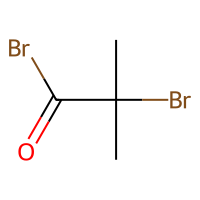

CC(C)(Br)C(=O)Br


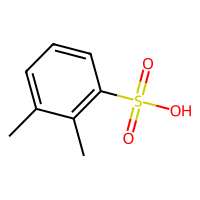

Cc1cccc(S(=O)(=O)O)c1C


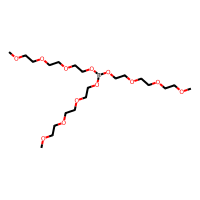

COCCOCCOCCOB(OCCOCCOCCOC)OCCOCCOCCOC


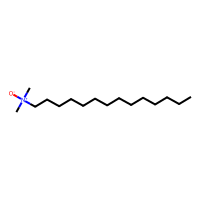

CCCCCCCCCCCCCC[N+](C)(C)[O-]


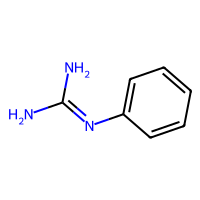

NC(N)=Nc1ccccc1


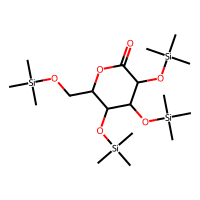

C[Si](C)(C)OCC1OC(=O)C(O[Si](C)(C)C)C(O[Si](C)(C)C)C1O[Si](C)(C)C


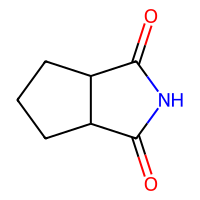

O=C1NC(=O)C2CCCC12


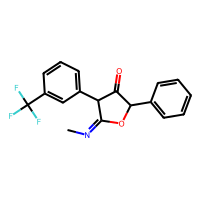

C/N=C1/OC(c2ccccc2)C(=O)C1c1cccc(C(F)(F)F)c1


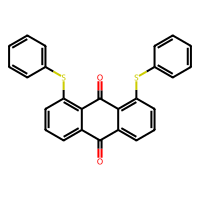

O=C1c2cccc(Sc3ccccc3)c2C(=O)c2c(Sc3ccccc3)cccc21


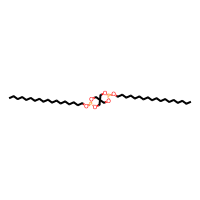

CCCCCCCCCCCCCCCCCCOP1OCC2(CO1)COP(OCCCCCCCCCCCCCCCCCC)OC2


In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(moldf, num_mols):
    for _, row in moldf.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 10)


In [7]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mordred import Calculator, descriptors
from fancyimpute import KNN


(CVXPY) Sep 19 04:47:37 PM: Encountered unexpected exception importing solver CVXOPT:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 19 04:47:37 PM: Encountered unexpected exception importing solver GLPK:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 19 04:47:37 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError('DLL load failed while importing base: The specified module could not be found.')


## 5. Descriptor

In [9]:
# Morgan fingerprints
nBits = 1024
radius = 2
useFeatures = False
moldf['Morgan_Descriptors'] = moldf['Mol'].apply(lambda mol: AllChem.GetMorganFingerprintAsBitVect(mol, nBits=nBits, radius=radius, useFeatures=useFeatures))

# MACCS keys
moldf['MACCS_Descriptors'] = moldf['Mol'].apply(lambda mol: MACCSkeys.GenMACCSKeys(mol))



In [10]:
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from mordred import Calculator, descriptors

# create descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=True)
df = calc.pandas(moldf['Mol'])

  0%|          | 9/8212 [00:03<30:59,  4.41it/s]  

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  6%|▋         | 530/8212 [00:09<01:10, 109.55it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  7%|▋         | 549/8212 [00:09<01:26, 88.35it/s] 

...

 40%|███▉      | 3266/8212 [00:51<02:13, 36.92it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 77%|███████▋  | 6331/8212 [01:35<01:15, 25.02it/s] 

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 8212/8212 [01:59<00:00, 68.51it/s] 


In [11]:
from fancyimpute import KNN
import pandas as pd
import numpy as np

# Assuming 'df' is your original DataFrame
df_numeric = df.select_dtypes(include=[float])  # Using Python's built-in float type

# Now run fancyimpute KNN, it returns a np.array which I store as a pandas dataframe
# Assuming the columns in df_numeric should be preserved for df_filled
df_filled = pd.DataFrame(KNN(k=3).fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)


Imputing row 1/8212 with 0 missing, elapsed time: 165.284
Imputing row 101/8212 with 0 missing, elapsed time: 165.285
Imputing row 201/8212 with 0 missing, elapsed time: 165.285
Imputing row 301/8212 with 0 missing, elapsed time: 165.286
Imputing row 401/8212 with 0 missing, elapsed time: 165.286
Imputing row 501/8212 with 0 missing, elapsed time: 165.287
Imputing row 601/8212 with 0 missing, elapsed time: 165.287
Imputing row 701/8212 with 0 missing, elapsed time: 165.288
Imputing row 801/8212 with 0 missing, elapsed time: 165.288
Imputing row 901/8212 with 0 missing, elapsed time: 165.288
Imputing row 1001/8212 with 0 missing, elapsed time: 165.289
Imputing row 1101/8212 with 0 missing, elapsed time: 165.289
Imputing row 1201/8212 with 0 missing, elapsed time: 165.290
Imputing row 1301/8212 with 0 missing, elapsed time: 165.290
Imputing row 1401/8212 with 0 missing, elapsed time: 165.290
Imputing row 1501/8212 with 0 missing, elapsed time: 165.291
Imputing row 1601/8212 with 0 missin

In [12]:
X = np.array(df_filled)
scaler = StandardScaler()
x=  scaler.fit_transform(X)
moldf['Modred_Descriptor'] = x.tolist()

In [13]:
print(x.shape)

(8212, 730)


In [14]:
moldf

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,ID,SMILES,Mol,GHS_category,EPA_category,LD50_mgkg,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
8064,20769-85-1,DTXSID7045077,2-Bromo-2-methylpropionyl bromide,EPA_DSSTox,CC(C)(Br)C(=O)Br,?,"InChI=1S/C4H6Br2O/c1-4(2,6)3(5)7/h1-2H3",YOCIJWAHRAJQFT-UHFFFAOYSA-N,FALSE,NA,...,20769-85-1,CC(C)(Br)C(=O)Br,<rdkit.Chem.rdchem.Mol object at 0x000002E469B...,NaN,NaN,NaN,8064,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.2726571063554268, -0.697303347132797, -0.6..."
7612,25321-41-9,DTXSID4027860,Xylenesulfonic acid,EPA_DSSTox,CC1C(=CC=CC=1C)S(O)(=O)=O,?,"InChI=1S/C8H10O3S/c1-6-4-3-5-8(7(6)2)12(9,10)1...",ZZXDRXVIRVJQBT-UHFFFAOYSA-N,FALSE,NA,...,25321-41-9,Cc1cccc(S(=O)(=O)O)c1C,<rdkit.Chem.rdchem.Mol object at 0x000002E468A...,NaN,3,NaN,7612,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7020024791362613, 0.2927225025475651, 0.39..."
8339,30989-05-0,DTXSID40184974,Tris(2-(2-(2-methoxyethoxy)ethoxy)ethyl) ortho...,EPA_DSSTox,COCCOCCOCCOB(OCCOCCOCCOC)OCCOCCOCCOC,?,InChI=1S/C21H45BO12/c1-23-4-7-26-10-13-29-16-1...,BYRJZJXBVKUYFH-UHFFFAOYSA-N,FALSE,NA,...,30989-05-0,COCCOCCOCCOB(OCCOCCOCCOC)OCCOCCOCCOC,<rdkit.Chem.rdchem.Mol object at 0x000002E469C...,NaN,NaN,NaN,8339,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.572074305160878, -0.9634594998748478, -0.92..."
8340,3332-27-2,DTXSID2029660,"1-Tetradecanamine, N,N-dimethyl-, N-oxide",EPA_DSSTox,CCCCCCCCCCCCCC[N+](C)(C)[O-],?,InChI=1S/C16H35NO/c1-4-5-6-7-8-9-10-11-12-13-1...,ONHFWHCMZAJCFB-UHFFFAOYSA-N,FALSE,NA,...,3332-27-2,CCCCCCCCCCCCCC[N+](C)(C)[O-],<rdkit.Chem.rdchem.Mol object at 0x000002E469C...,NaN,NaN,NaN,8340,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[-0.12606942975685204, -0.9628603140261726, -0..."
7611,6685-76-3,DTXSID70216974,"Carbonic acid, compound with phenylguanidine (...",EPA_DSSTox,NC(N)=NC1C=CC=CC=1,OC(O)=O,"InChI=1S/C7H9N3/c8-7(9)10-6-4-2-1-3-5-6/h1-5H,...",QRJZGVVKGFIGLI-UHFFFAOYSA-N,FALSE,NA,...,6685-76-3,NC(N)=Nc1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x000002E468A...,NaN,3,NaN,7611,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.837063384576445, -0.6973033471328014, -0.6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3978,123886-69-1,DTXSID60154134,"2H-1-Benzopyran, 3,4-dihydro-7-methoxy-2,2-dim...",EPA_DSSTox,COC1C=CC2C(C(C3C=CC=CC=3)C(C)(C)OC=2C=1)C1C=CC...,?,InChI=1S/C27H28O3/c1-5-17-29-21-13-11-19(12-14...,IDDRFDFLMSNJBD-UHFFFAOYSA-N,FALSE,FALSE,...,123886-69-1,C=CCOc1ccc(C2c3ccc(OC)cc3OC(C)(C)C2c2ccccc2)cc1,<rdkit.Chem.rdchem.Mol object at 0x000002E4643...,4,2,500.0,3978,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.3283429159831266, 1.1942358458640372, 1.342..."
3977,123886-68-0,DTXSID00154133,"2H-1-Benzopyran, 4-(4-(2-bromoethoxy)phenyl)-3...",EPA_DSSTox,COC1C=CC2C(C(C3C=CC=CC=3)C(C)(C)OC=2C=1)C1C=CC...,?,InChI=1S/C26H27BrO3/c1-26(2)25(19-7-5-4-6-8-19...,RAXILLWCRCHLGT-UHFFFAOYSA-N,FALSE,FALSE,...,123886-68-0,COc1ccc2c(c1)OC(C)(C)C(c1ccccc1)C2c1ccc(OCCBr)cc1,<rdkit.Chem.rdchem.Mol object at 0x000002E4643...,4,2,500.0,3977,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.3283429159831261, 1.1942358458640285, 1.342..."
3976,123886-62-4,DTXSID50154128,"Ethanol, 2-(4-(7-methoxy-2,2-dimethyl-3-phenyl...",EPA_DSSTox,COC1C=CC2=C(C=1)OC(C)(C)C(=C2C1C=CC(=CC=1)OCCO...,?,InChI=1S/C26H26O4/c1-26(2)25(19-7-5-4-6-8-19)2...,MABKBYVHTXAUDN-UHFFFAOYSA-N,FALSE,FALSE,...,123886-62-4,COc1ccc2c(c1)OC(C)(C)C(c1ccccc1)=C2c1ccc(OCCO)cc1,<rdkit.Chem.rdchem.Mol object at 0x000002E46

In [15]:
moldf.keys()

Index(['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'SMILES', 'Mol',
       'GHS_category', 'EPA_category', 'LD50_mgkg', 'RowID',
       'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor'],
      dtype='object')

In [17]:
data = moldf

In [18]:
data.keys()

Index(['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'SMILES', 'Mol',
       'GHS_category', 'EPA_category', 'LD50_mgkg', 'RowID',
       'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor'],
      dtype='object')

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect



# Remove duplicate columns
data = data.loc[:, ~data.columns.duplicated()]

# Split the data into train and test sets
train, test = train_test_split(data, test_size=0.2, random_state=42)

# Function to convert bit vectors to a list of integers
def bitvector_to_list(bitvector):
    if isinstance(bitvector, ExplicitBitVect):
        return list(map(int, bitvector.ToBitString()))
    else:
        return bitvector

# Convert bit vectors to lists before saving
def convert_bit_vectors(df):
    if 'Morgan_Descriptors' in df.columns:
        df['Morgan_Descriptors'] = df['Morgan_Descriptors'].apply(bitvector_to_list)
    if 'MACCS_Descriptors' in df.columns:
        df['MACCS_Descriptors'] = df['MACCS_Descriptors'].apply(bitvector_to_list)
    return df

# Convert bit vectors for train and test sets
train = convert_bit_vectors(train)
test = convert_bit_vectors(test)

# Function to save DataFrame to SDF
def save_to_sdf(df, filename):
    sdf_writer = Chem.SDWriter(filename)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mol.SetProp("_Name", str(idx))
            for col in df.columns:
                if col != 'Mol' and col != 'SMILES':
                    mol.SetProp(col, str(row[col]))
            sdf_writer.write(mol)
    sdf_writer.close()


# Save the train and test sets to SDF files
save_to_sdf(train, 'C:/Users/USER-PC/QSAR_Code/Oral toxicity/dataset/train_set_acute_oral_features.sdf')
save_to_sdf(test, 'C:/Users/USER-PC/QSAR_Code/Oral toxicity/dataset/tes_set_acute_oral_features.sdf')

print("Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.")


Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.


In [20]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Oral toxicity/dataset/train_set_acute_oral_features.sdf')
test_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Oral toxicity/dataset/train_set_acute_oral_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

print("Test DataFrame:")
print(test_df.head())


Train DataFrame:
        CASRN          DTXSID  \
0  62899-75-6             nan   
1  15351-05-0             nan   
2    633-99-8  DTXSID50212691   
3  68955-20-4   DTXSID8029523   
4  84731-70-4             nan   

                                                Name     Structure_Source  \
0                                                     Public_CrossChecked   
1                                                     Public_CrossChecked   
2                                1-Chloro-2-naphthol           EPA_DSSTox   
3  Sulfuric acid, mono-C16-18-alkyl esters, sodiu...           EPA_DSSTox   
4                                                     Public_CrossChecked   

                                     Canonical_QSARr Salt_Solvent  \
0                               CCN(C1CCCCC1)C(=O)Cl            ?   
1  C[N+]1(CCC(C(N)=O)(C2C=CC=CC=2)C2C=CC=CC=2)CCC...         [I-]   
2                             OC1C=CC2=CC=CC=C2C=1Cl            ?   
3                       CCCCCCCCCCCCCCCCCOS(O

In [21]:
train_df

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,Outcome,ID,GHS_category,EPA_category,LD50_mgkg,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
0,62899-75-6,nan,,Public_CrossChecked,CCN(C1CCCCC1)C(=O)Cl,?,InChI=1S/C9H16ClNO/c1-2-11(9(10)12)8-6-4-3-5-7...,ONKIPJDBUYZQMP-UHFFFAOYSA-N,FALSE,FALSE,...,1,62899-75-6,4,2,nan,7608,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6310028966353155, -0.2132696043052749, -0....",CCN(C(=O)Cl)C1CCCCC1
1,15351-05-0,nan,,Public_CrossChecked,C[N+]1(CCC(C(N)=O)(C2C=CC=CC=2)C2C=CC=CC=2)CCC...,[I-],InChI=1S/C23H30N2O/c1-25(17-10-2-3-11-18-25)19...,HDGFUOKLIQJQCS-UHFFFAOYSA-O,FALSE,TRUE,...,0,15351-05-0,5,3,2800.0,6207,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8748341647711342, 0.8995412750917375, 1.030...",C[N+]1(CCC(C(N)=O)(c2ccccc2)c2ccccc2)CCCCCC1
2,633-99-8,DTXSID50212691,1-Chloro-2-naphthol,EPA_DSSTox,OC1C=CC2=CC=CC=C2C=1Cl,?,InChI=1S/C10H7ClO/c11-10-8-4-2-1-3-7(8)5-6-9(1...,RMSOEGBYNWXXBG-UHFFFAOYSA-N,FALSE,TRUE,...,0,633-99-8,5,3,2310.0,6007,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5392918709541767, 0.3428387313135868, 0.44...",Oc1ccc2ccccc2c1Cl
3,68955-20-4,DTXSID8029523,"Sulfuric acid, mono-C16-18-alkyl esters, sodiu...",EPA_DSSTox,CCCCCCCCCCCCCCCCCOS(O)(=O)=O,[Na+],InChI=1S/C17H36O4S/c1-2-3-4-5-6-7-8-9-10-11-12...,KGIBGHABTNQVJX-UHFFFAOYSA-N,FALSE,FALSE,...,1,68955-20-4,4,3,nan,298,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2793936699423021, -0.9628230036979278, -0.9...",CCCCCCCCCCCCCCCCCOS(=O)(=O)O
4,84731-70-4,nan,,Public_CrossChecked,CCCCC(COC(=O)C1CCC(CC1)C(=O)OCC(CCCC)CC)CC,?,InChI=1S/C24H44O4/c1-5-9-11-19(7-3)17-27-23(25...,HOQGHOMLEVKTBY-UHFFFAOYSA-N,FALSE,TRUE,...,0,84731-70-4,5,3,nan,878,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9913975845162339, -0.024890738301124374, 0....",CCCCC(CC)COC(=O)C1CCC(C(=O)OCC(CC)CCCC)CC1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6564,80464-05-7,nan,,Public_CrossChecked,CN(C)C1C=CC(=CC=1)NC(=O)CCCSC1=NN=NN1C,?,InChI=1S/C14H20N6OS/c1-19(2)12-8-6-11(7-9-12)1...,WKLKPZAMTNLNQV-UHFFFAOYSA-N,FALSE,FALSE,...,1,80464-05-7,4,3,nan,351,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.39459793795032455, -0.200120698926252, -0.1...",CN(C)c1ccc(NC(=O)CCCSc2nnnn2C)cc1
6565,64050-54-0,DTXSID60214181,"1H-Benz(de)isoquinoline-1,3(2H)-dione, 2-((dim...",EPA_DSSTox,COP(=O)(ON1C(=O)C2C=CC=C3C=CC=C(C3=2)C1=O)OC,?,"InChI=1S/C14H12NO6P/c1-19-22(18,20-2)21-15-13(...",SFWMYVAUEVMHSH-UHFFFAOYSA-N,FALSE,FALSE,...,1,64050-54-0,3,2,70.0,2720,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0.4937554848531204, 1.1095184090253212, 1.253...",COP(=O)(OC)ON1C(=O)c2cccc3cccc(c23)C1=O
6566,6900-06-7,DTXSID90219043,"Adipic acid, di-2-propynyl ester",EPA_DSSTox,C#CCOC(=O)CCCCC(=O)OCC#C,?,InChI=1S/C12H14O4/c1-3-9-15-11(13)7-5-6-8-12(1...,UUKXRCZQOHIIPD-UHFFFAOYSA-N,FALSE,FALSE,...,1,6900-06-7,3,2,200.0,3232,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2545282451570665, -1.18640488650259, -1.15...",C#CCOC(=O)CCCCC(=O)OCC#C
6567,6837-93-0,DTXSID00218502,"2,7-Naphthalenedisulfonic acid, 4-amino-5-hydr...",EPA_DSSTox,CC1C=CC(=CC=1)S(=O)(=O)OC1=CC(=CC2=CC(=CC(N)=C...,?,InChI=1S/C17H15NO9S3/c1-10-2-4-12(5-3-10)30(25...,ZIQWUYNDHGXLIN-UHFFFAOYSA-N,FALSE,TRUE,...,0,6837-93-0,5,4,11500.0,7331,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0109522027754958, 0.9812949155776244, 1.119...",Cc1ccc(S(=O)(=O)O

In [22]:
train

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,ID,SMILES,Mol,GHS_category,EPA_category,LD50_mgkg,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
7608,62899-75-6,NaN,,Public_CrossChecked,CCN(C1CCCCC1)C(=O)Cl,?,InChI=1S/C9H16ClNO/c1-2-11(9(10)12)8-6-4-3-5-7...,ONKIPJDBUYZQMP-UHFFFAOYSA-N,FALSE,FALSE,...,62899-75-6,CCN(C(=O)Cl)C1CCCCC1,<rdkit.Chem.rdchem.Mol object at 0x000002E468A...,4,2,NaN,7608,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6310028966353155, -0.2132696043052749, -0...."
6207,15351-05-0,NaN,,Public_CrossChecked,C[N+]1(CCC(C(N)=O)(C2C=CC=CC=2)C2C=CC=CC=2)CCC...,[I-],InChI=1S/C23H30N2O/c1-25(17-10-2-3-11-18-25)19...,HDGFUOKLIQJQCS-UHFFFAOYSA-O,FALSE,TRUE,...,15351-05-0,C[N+]1(CCC(C(N)=O)(c2ccccc2)c2ccccc2)CCCCCC1,<rdkit.Chem.rdchem.Mol object at 0x000002E4677...,5,3,2800.0,6207,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8748341647711342, 0.8995412750917375, 1.030..."
6007,633-99-8,DTXSID50212691,1-Chloro-2-naphthol,EPA_DSSTox,OC1C=CC2=CC=CC=C2C=1Cl,?,InChI=1S/C10H7ClO/c11-10-8-4-2-1-3-7(8)5-6-9(1...,RMSOEGBYNWXXBG-UHFFFAOYSA-N,FALSE,TRUE,...,633-99-8,Oc1ccc2ccccc2c1Cl,<rdkit.Chem.rdchem.Mol object at 0x000002E4667...,5,3,2310.0,6007,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5392918709541767, 0.3428387313135868, 0.44..."
298,68955-20-4,DTXSID8029523,"Sulfuric acid, mono-C16-18-alkyl esters, sodiu...",EPA_DSSTox,CCCCCCCCCCCCCCCCCOS(O)(=O)=O,[Na+],InChI=1S/C17H36O4S/c1-2-3-4-5-6-7-8-9-10-11-12...,KGIBGHABTNQVJX-UHFFFAOYSA-N,FALSE,FALSE,...,68955-20-4,CCCCCCCCCCCCCCCCCOS(=O)(=O)O,<rdkit.Chem.rdchem.Mol object at 0x000002E45EC...,4,3,NaN,298,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2793936699423021, -0.9628230036979278, -0.9..."
878,84731-70-4,NaN,,Public_CrossChecked,CCCCC(COC(=O)C1CCC(CC1)C(=O)OCC(CCCC)CC)CC,?,InChI=1S/C24H44O4/c1-5-9-11-19(7-3)17-27-23(25...,HOQGHOMLEVKTBY-UHFFFAOYSA-N,FALSE,TRUE,...,84731-70-4,CCCCC(CC)COC(=O)C1CCC(C(=O)OCC(CC)CCCC)CC1,<rdkit.Chem.rdchem.Mol object at 0x000002E45FD...,5,3,NaN,878,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9913975845162339, -0.024890738301124374, 0...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,80464-05-7,NaN,,Public_CrossChecked,CN(C)C1C=CC(=CC=1)NC(=O)CCCSC1=NN=NN1C,?,InChI=1S/C14H20N6OS/c1-19(2)12-8-6-11(7-9-12)1...,WKLKPZAMTNLNQV-UHFFFAOYSA-N,FALSE,FALSE,...,80464-05-7,CN(C)c1ccc(NC(=O)CCCSc2nnnn2C)cc1,<rdkit.Chem.rdchem.Mol object at 0x000002E45FC...,4,3,NaN,351,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.39459793795032455, -0.200120698926252, -0.1..."
2720,64050-54-0,DTXSID60214181,"1H-Benz(de)isoquinoline-1,3(2H)-dione, 2-((dim...",EPA_DSSTox,COP(=O)(ON1C(=O)C2C=CC=C3C=CC=C(C3=2)C1=O)OC,?,"InChI=1S/C14H12NO6P/c1-19-22(18,20-2)21-15-13(...",SFWMYVAUEVMHSH-UHFFFAOYSA-N,FALSE,FALSE,...,64050-54-0,COP(=O)(OC)ON1C(=O)c2cccc3cccc(c23)C1=O,<rdkit.Chem.rdchem.Mol object at 0x000002E4630...,3,2,70.0,2720,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0.4937554848531204, 1.1095184090253212, 1.253..."
3232,6900-06-7,DTXSID90219043,"Adipic acid, di-2-propynyl ester",EPA_DSSTox,C#CCOC(=O)CCCCC(=O)OCC#C,?,InChI=1S/C12H14O4/c1-3-9-15-11(13)7-5-6-8-12(1...,UUKXRCZQOHIIPD-UHFFFAOYSA-N,FALSE,FALSE,...,6900-06-7,C#CCOC(=O)CCCCC(=O)OCC#C,<rdkit.Chem.rdchem.Mol object at 0x000002E4631...,3,2,200.0,3232,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2545282451570665, -1.18640488650259, -1.15..."
7331,6837-93-0,DTXSID00218502,"2,7-Naphthalenedi